# ScanVI label transfer

scANVI currently set to 20 epochs; may need to increase.

12/02 removed this --  (adata_concat.obs["total_counts"] < 800))

In [1]:
from pathlib import Path
import os
import scanpy as sc
from scipy.sparse import issparse
import scvi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import anndata as ad
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


In [3]:
base_dir = Path('/home/workspace/projects/drg')

adata_dir = base_dir / "data/h5ad/export_02/02b_leiden"
ref_data_dir = '/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/05_reference' # Concatenated dataset

output_dir = base_dir / "data/h5ad/export_03/03a_scanvi"
scanvi_dir = base_dir / 'scanvi' # csv output
scvi_dir = base_dir / 'scvi/neuron_scanvi'

scanvi_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

In [4]:
adata = sc.read_h5ad(os.path.join(adata_dir, 'adata-leiden-475.h5ad'))
refdata = sc.read_h5ad(os.path.join(ref_data_dir, 'adata-reference.h5ad'))

### Prepare AnnDatas

In [5]:
# Rename existing real "Unknown" annotation for scanvi script to work
refdata.obs["cell_label"] = (
    refdata.obs["cell_label"]
    .replace({"Unknown": "Unassigned"})
)

refdata.obs.cell_label.value_counts()

/tmp/ipykernel_10789/1359022782.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace({"Unknown": "Unassigned"})


cell_label
SGC                           15210
Vascular_endothelial_1         5007
Schwann_cell                   2699
Nonpeptidergic nociceptors     2669
CGRP-Alpha                     1440
C-LTMR                         1415
CGRP-Epsilion                   848
Sst                             757
CGRP-Theta                      735
CGRP-Gamma                      696
Pericyte                        605
TrpM8                           485
Vascular_endothelial_2          429
Macrophage_1                    405
Cycling SGC                     340
CGRP-Zeta                       321
Fibroblast_1                    282
Abeta-RA-LTMR                   265
CGRP-Eta                        257
Abeta-Field                     245
Proprioceptors                  228
Fibroblast_2                    207
Angiogenic EC                   182
Adelta-LTMR                     153
Macrophage_2                    146
CGRP-Beta                       134
Unassigned                       81
Name: count, dtyp

In [6]:
adata.obs["experiment_id"] = "Xenium" # experiment_id will be used as batch key

In [7]:
print(refdata.layers)
print(adata.layers)

Layers with keys: counts, log1p, normalized_1e6
Layers with keys: counts


In [8]:
# restore raw counts, assign same name as query adata
#refdata.layers['counts'] = refdata.layers['raw'].copy()  # Store raw counts
#refdata.X = refdata.layers['counts'].copy()  # Set X to use raw counts

In [9]:
adata.X = adata.layers['counts'].copy()

In [10]:
adata.X[:5, :5].toarray()  # Convert and preview first 5x5 matrix elements

array([[ 0.,  2.,  0.,  2.,  0.],
       [ 3., 20.,  1., 25.,  0.],
       [ 1.,  1.,  5., 13.,  0.],
       [ 0.,  1.,  0.,  0.,  0.],
       [ 0.,  4.,  0.,  9.,  0.]], dtype=float32)

In [11]:
print(refdata.X[:5, :5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15 stored elements and shape (5, 5)>
  Coords	Values
  (0, 4)	2.0
  (0, 1)	4.0
  (1, 4)	2.0
  (1, 3)	1.0
  (1, 2)	1.0
  (1, 1)	2.0
  (1, 0)	2.0
  (2, 2)	1.0
  (2, 1)	2.0
  (3, 4)	2.0
  (3, 1)	1.0
  (3, 0)	3.0
  (4, 4)	4.0
  (4, 1)	3.0
  (4, 0)	2.0


In [12]:
# add output_id for refdata
#refdata.obs['output_id'] = refdata.obs['batch']
#refdata.obs.output_id.value_counts()

In [13]:
# add column up here for filtering later only on refdata
refdata.obs['ref_data'] = 'Yes'
adata.obs['ref_data'] = 'No'

## Gene alignment and concatenation

In [14]:
# Find the intersection of genes for integration
common_genes = list(set(adata.var_names) & set(refdata.var_names))
len(common_genes)

471

### Create subsets

In [15]:
# Create copies of the datasets, keeping only common genes
adata_subset = adata[:, common_genes].copy()
refdata_subset = refdata[:, common_genes].copy()

In [16]:
print(f"adata before subsetting: {adata.shape[1]}")
print(f"adata after subsetting: {adata_subset.shape[1]}")

print(f"refdata before subsetting: {refdata.shape[1]}")
print(f"refdata after subsetting: {refdata_subset.shape[1]}")

adata before subsetting: 480
adata after subsetting: 471
refdata before subsetting: 28737
refdata after subsetting: 471


In [17]:
index_match = (adata_subset.var_names == refdata_subset.var_names).all()
print(f"adata.var_names match: {index_match}")

adata.var_names match: True


# Concatenate

In [18]:
print(adata_subset.obs.columns)
print(refdata_subset.obs.columns)

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id',
       'output_id', 'region_id', 'slide_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes',
       'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch',
       '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data'],
      dtype='object')
Index(['original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id',
       'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt',
       'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal',
       'doublet_scores

In [19]:
# Concatenate datasets
adata_list = [adata_subset, refdata_subset]

adata_concat = ad.concat(adata_list, 
                  join="outer", # make sure it's outer
                  label = 'scanvi_batch',
                  index_unique="-")

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/anndata/_core/merge.py:1358: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [20]:
adata_concat # confirm number genes

AnnData object with n_obs × n_vars = 182517 × 471
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'artifact', 'class', 'cell_type', 'cell_label', 'scanvi_batch'
    obsm: 'X_scVI_ModelB_480', 'X_umap', 'spatial', 'X_scVI'
    layers: 'coun

In [21]:
adata_concat.obs.output_id.value_counts()

output_id
output-XETG00123__0052281__TMA00305__20251108__004334    32361
output-XETG00123__0052334__TMA00306__20251108__004334    31535
output-XETG00123__0052334__TMA00304__20251108__004334    21020
output-XETG00123__0052046__TMA00311__20251119__221941    19336
output-XETG00123__0052399__TMA00312__20251119__221941    17302
output-XETG00123__0052281__TMA00303__20251108__004334    11122
output-XETG00123__0052046__TMA00307__20251119__221941     6835
output-XETG00123__0052399__TMA00308__20251119__221941     6765
Name: count, dtype: int64

### Perform filtering on concatenated adata

In [22]:
sc.pp.calculate_qc_metrics(adata_concat, percent_top=(10, 20, 50, 150), inplace=True) # adds total_counts metric for filtering

In [23]:
print(f"Empty cell check (min, max): {adata_concat.X.sum(axis=1).min()}, {adata_concat.X.sum(axis=1).max()}")

Empty cell check (min, max): 13.0, 11772.0


12/02 - Revise scanvi logic here to not have a total_counts ceiling

In [24]:
# or operator ensures that rows satisfying at least one condition are kept
# so if adata.obs.ref_data = No (study samples), then the cell is kept
# OR if adata.obs.ref_data = Yes AND the cell has acceptable total counts the row is also kept

adata_concat = adata_concat[
    (adata_concat.obs["ref_data"] == "No") | # Keep all non-reference samples
    (
        (adata_concat.obs["ref_data"] == "Yes") & # Apply total_counts filter only to reference samples
        (adata_concat.obs["total_counts"] > 20)
    )
].copy()

In [25]:
print(f"Empty cell check (min, max): {adata_concat.X.sum(axis=1).min()}, {adata_concat.X.sum(axis=1).max()}")

Empty cell check (min, max): 15.0, 11772.0


# Examine Batch Effects

In [26]:
adata_concat.X[:5, :5].toarray()

array([[0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0.]])

In [27]:
# Normalize and run PCA
sc.pp.normalize_total(adata_concat)
sc.pp.log1p(adata_concat)
sc.pp.pca(adata_concat, n_comps = 10, random_state = 0) # added arguments 12/2 to reduce PCA calculation for better visualization

# UMAP colored by output_id
sc.pp.neighbors(adata_concat, n_pcs = 10)
sc.tl.umap(adata_concat)

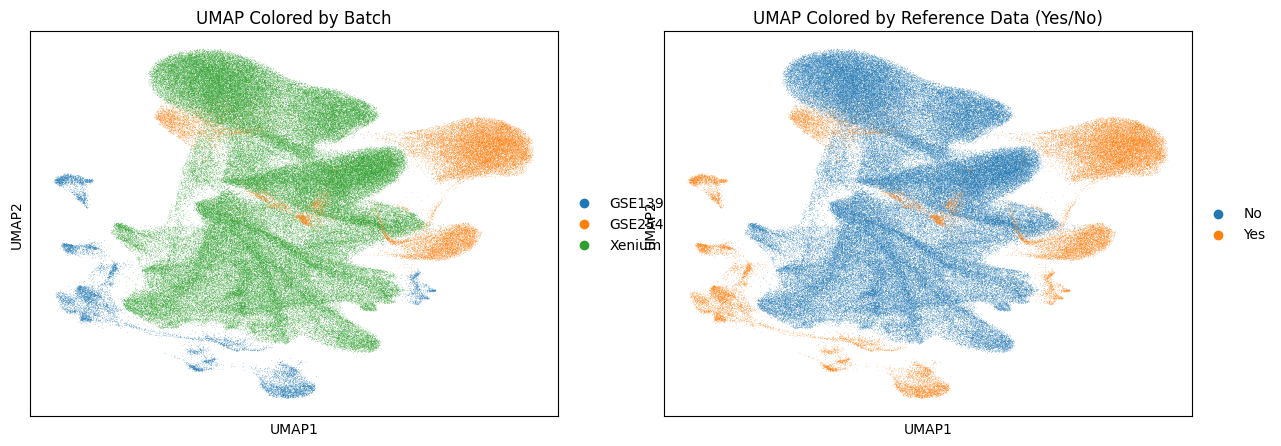

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot UMAP by batch identifier
sc.pl.umap(adata_concat, color="experiment_id", show=False, ax=axes[0])
axes[0].set_title("UMAP Colored by Batch")

# Plot UMAP by ref_data
sc.pl.umap(adata_concat, color="ref_data", show=False, ax=axes[1])
axes[1].set_title("UMAP Colored by Reference Data (Yes/No)")

plt.show()
plt.close()

## Train scVI model

In [29]:
adata_concat

AnnData object with n_obs × n_vars = 182485 × 471
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'artifact', 'class', 'cell_type', 'cell_label', 'scanvi_batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout

In [30]:
# Check batch key
adata_concat.obs["experiment_id"] = adata_concat.obs["experiment_id"].astype("category")
adata_concat.obs["experiment_id"] = pd.Categorical(adata_concat.obs["experiment_id"])
adata_concat.obs['experiment_id'].value_counts()

experiment_id
Xenium       146276
GSE254789     25480
GSE139088     10729
Name: count, dtype: int64

In [31]:
scvi.model.SCVI.setup_anndata(
    adata_concat, 
    layer="counts", # use raw count data
    batch_key='experiment_id', # biggest batch effect is panel; 12/02 
)

model = scvi.model.SCVI(adata_concat)
print('starting model training')

model.train(early_stopping=True, 
            enable_progress_bar=True,
            accelerator = 'gpu'
           )

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


starting model training


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 44/44: 100%|██████████| 44/44 [09:08<00:00, 12.47s/it, v_num=1, train_loss_step=277, train_loss_epoch=221]

`Trainer.fit` stopped: `max_epochs=44` reached.


Epoch 44/44: 100%|██████████| 44/44 [09:08<00:00, 12.46s/it, v_num=1, train_loss_step=277, train_loss_epoch=221]


In [32]:
model.save(os.path.join(scvi_dir, '02_model') , prefix='02_label_transfer_')

In [33]:
SCVI_LATENT_KEY = "X_scVI_refalign"
adata_concat.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

### Compute neighbors graph and UMAP

In [34]:
# neighbors
sc.pp.neighbors(adata_concat, use_rep="X_scVI_refalign", key_added='neighbors_scvi_refalign')
sc.tl.umap(adata_concat, neighbors_key='neighbors_scvi_refalign')

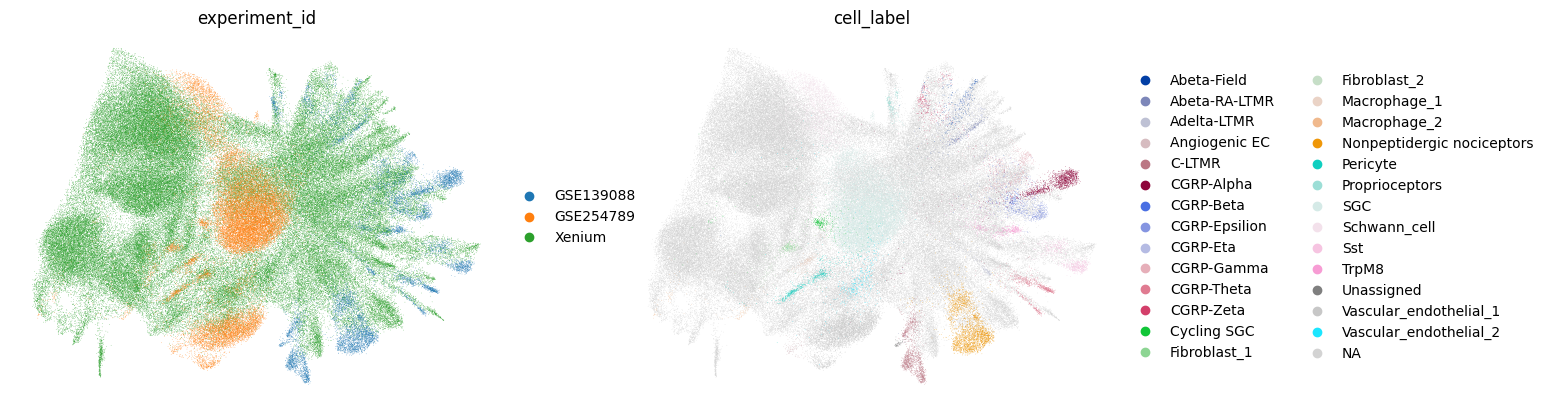

In [35]:
sc.pl.umap(adata_concat, color = ['experiment_id', 'cell_label'], frameon = False)

### Export refaligned adata

In [36]:
# save umap dims to csv
umap_df = pd.DataFrame(adata_concat.obsm['X_umap'], index=adata_concat.obs_names, columns=['umap1', 'umap2'])
filename = os.path.join(scanvi_dir, 'adata_scvi_refalign_umap_coords.csv')
umap_df.to_csv(filename)

In [37]:
filename = os.path.join(output_dir, 'adata_concat_scvi_refalign.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata_concat.write_h5ad(filename, compression='gzip')

# Checkpoint

In [38]:
filename = os.path.join(output_dir, 'adata_concat_scvi_refalign.h5ad')
adata_concat = sc.read_h5ad(filename)
adata_concat

AnnData object with n_obs × n_vars = 182485 × 471
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data', 'original_annotation', 'GSE', 'GSM', 'sample_number', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'leiden', 'artifact', 'class', 'cell_type', 'cell_label', 'scanvi_batch'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout

### Prep data for scANVI

In [39]:
adata_concat.obs.columns

Index(['cell_id', 'x_centroid', 'y_centroid', 'transcript_counts',
       'control_probe_counts', 'genomic_control_counts',
       'control_codeword_counts', 'unassigned_codeword_counts',
       'deprecated_codeword_counts', 'total_counts', 'cell_area',
       'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id',
       'output_id', 'region_id', 'slide_id', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'log1p_total_counts',
       'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes',
       'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch',
       '_scvi_labels', 'leiden_scVI_1', 'experiment_id', 'ref_data',
       'original_annotation', 'GSE', 'GSM', 'sample_number', 'total_counts_mt',
       'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal',
       'leiden', 'artifact', 'class', 'cell_type', 'cell_label',
       'scanvi_batch'],
      dtype='object')

In [40]:
# Add 'Unknown' category for original samples if missing, then fill NaN
if 'Unknown' not in adata_concat.obs['cell_label'].cat.categories:
    adata_concat.obs['cell_label'] = adata_concat.obs['cell_label'].cat.add_categories('Unknown')

adata_concat.obs = adata_concat.obs.fillna(value={'cell_label': 'Unknown'})

In [41]:
adata_concat.obs['cell_label'].value_counts() # confirm that cell_label is the most granular

cell_label
Unknown                       146276
SGC                            15184
Vascular_endothelial_1          5007
Schwann_cell                    2697
Nonpeptidergic nociceptors      2669
CGRP-Alpha                      1440
C-LTMR                          1415
CGRP-Epsilion                    848
Sst                              757
CGRP-Theta                       735
CGRP-Gamma                       696
Pericyte                         605
TrpM8                            485
Vascular_endothelial_2           429
Macrophage_1                     401
Cycling SGC                      340
CGRP-Zeta                        321
Fibroblast_1                     282
Abeta-RA-LTMR                    265
CGRP-Eta                         257
Abeta-Field                      245
Proprioceptors                   228
Fibroblast_2                     207
Angiogenic EC                    182
Adelta-LTMR                      153
Macrophage_2                     146
CGRP-Beta                  

Below is important for mapping labels in the unintegrated original adata

In [42]:
# Subset only query dataset (unlabeled before scANVI training)
query_cells = adata_concat.obs["cell_label"] == "Unknown"
query_cells.to_csv(os.path.join(scanvi_dir, 'query_cells-subtype.csv'))
query_cells

aaagciof-1-0-0                        True
aaailodo-1-0-0                        True
aaanacfp-1-0-0                        True
aaaohjeo-1-0-0                        True
aabfmjal-1-0-0                        True
                                     ...  
GSM8057829_TTTGGAGAGTCGGGAT-1-1-1    False
GSM8057829_TTTGGAGTCCAAACCA-1-1-1    False
GSM8057829_TTTGGTTTCCAACCGG-1-1-1    False
GSM8057829_TTTGTTGTCCCTTTGG-1-1-1    False
GSM8057829_TTTGTTGTCCTAAACG-1-1-1    False
Name: cell_label, Length: 182485, dtype: bool

In [43]:
# fix barcodes; suffix was added during concat
query_cells_copy = query_cells.copy()
query_cells_copy.index = query_cells_copy.index.map(lambda x: x[:-2])
query_cells_copy

aaagciof-1-0                        True
aaailodo-1-0                        True
aaanacfp-1-0                        True
aaaohjeo-1-0                        True
aabfmjal-1-0                        True
                                   ...  
GSM8057829_TTTGGAGAGTCGGGAT-1-1    False
GSM8057829_TTTGGAGTCCAAACCA-1-1    False
GSM8057829_TTTGGTTTCCAACCGG-1-1    False
GSM8057829_TTTGTTGTCCCTTTGG-1-1    False
GSM8057829_TTTGTTGTCCTAAACG-1-1    False
Name: cell_label, Length: 182485, dtype: bool

## Run scANVI

In [44]:
# scanvi label transfer
scanvi_model = scvi.model.SCANVI.from_scvi_model(model, 
                                                 adata = adata_concat, 
                                                 unlabeled_category = 'Unknown', # Entries in labels_key to label
                                                 labels_key = 'cell_label') # Column to transfer labels from

scanvi_model.train(max_epochs=20, 
                   accelerator = 'gpu',
                   n_samples_per_label = None) # this is longer training because it's not subsampling

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


INFO     Training for 20 epochs.                                                                                   


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 20/20: 100%|██████████| 20/20 [09:53<00:00, 29.70s/it, v_num=1, train_loss_step=206, train_loss_epoch=215]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [09:53<00:00, 29.69s/it, v_num=1, train_loss_step=206, train_loss_epoch=215]


In [45]:
# save scANVI model
scanvi_model.save(os.path.join(scvi_dir, '03_model_scanvi') , prefix='03_scanvi_')

### Reference mapping step

In [46]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "scanvi_labels"

adata_concat.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata_concat)
adata_concat.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata_concat) # this fills out the labels

In [47]:
adata_concat.obs['scanvi_labels'].value_counts()

scanvi_labels
Schwann_cell                  32705
SGC                           29297
Macrophage_2                  16249
Vascular_endothelial_1        12732
Nonpeptidergic nociceptors    10382
Cycling SGC                   10007
CGRP-Gamma                     9189
Fibroblast_2                   7106
Macrophage_1                   5020
Fibroblast_1                   4842
C-LTMR                         4528
Vascular_endothelial_2         4268
TrpM8                          4099
CGRP-Eta                       3841
Abeta-RA-LTMR                  3743
CGRP-Alpha                     3667
Pericyte                       3420
CGRP-Zeta                      3062
Sst                            2660
CGRP-Epsilion                  2638
CGRP-Theta                     2437
Adelta-LTMR                    2417
Abeta-Field                    1457
Proprioceptors                 1219
Angiogenic EC                  1207
CGRP-Beta                       178
Unassigned                      115
Name: count, d

In [48]:
filename = os.path.join(output_dir, 'adata_concat-scvi-scanvi-predictions.h5ad')
os.makedirs(os.path.dirname(filename), exist_ok = True)

adata_concat.write_h5ad(filename, compression='gzip')

## Map query labels onto original adata

In [49]:
# re-read fresh adata with all the genes, this is the query
adata_query = sc.read_h5ad(os.path.join(adata_dir, 'adata-leiden-475.h5ad'))
adata_query.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,pct_counts_in_top_10_genes,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_150_genes,doublet_scores,predicted_doublets,batch,_scvi_batch,_scvi_labels,leiden_scVI_1
aaagciof-1-0,aaagciof-1,634.049133,299.172485,347,0,0,0,0,0,347.0,...,29.106628,46.974063,74.351585,100.000000,0.053711,False,0,1,0,20
aaailodo-1-0,aaailodo-1,609.569763,308.822144,2415,0,0,0,0,0,2415.0,...,34.492754,52.091097,77.060041,98.053830,0.056738,False,0,1,0,11
aaanacfp-1-0,aaanacfp-1,634.638367,309.968719,1937,0,0,0,0,0,1937.0,...,36.964378,55.962829,83.840991,99.690243,0.061728,False,0,1,0,20
aaaohjeo-1-0,aaaohjeo-1,627.379822,297.124298,479,0,0,0,0,0,479.0,...,33.611691,49.686848,73.277662,100.000000,0.041356,False,0,1,0,10
aabfmjal-1-0,aabfmjal-1,621.577148,367.691040,402,0,0,0,0,0,402.0,...,47.761194,61.691542,82.338308,100.000000,0.030748,False,0,1,0,3


In [50]:
# create adata_labeled from adata_concat which has the labels
adata_labeled = adata_concat[adata_concat.obs['scanvi_batch'] == '0'].copy() # batch is stored as string

print(adata_labeled.obs['scanvi_batch'].value_counts())
print('')
print(adata_labeled.obs['output_id'].value_counts())

scanvi_batch
0    146276
Name: count, dtype: int64

output_id
output-XETG00123__0052281__TMA00305__20251108__004334    32361
output-XETG00123__0052334__TMA00306__20251108__004334    31535
output-XETG00123__0052334__TMA00304__20251108__004334    21020
output-XETG00123__0052046__TMA00311__20251119__221941    19336
output-XETG00123__0052399__TMA00312__20251119__221941    17302
output-XETG00123__0052281__TMA00303__20251108__004334    11122
output-XETG00123__0052046__TMA00307__20251119__221941     6835
output-XETG00123__0052399__TMA00308__20251119__221941     6765
Name: count, dtype: int64


In [51]:
# Remove suffix from labeled adata subset from adata_concat
adata_labeled.obs.index = adata_labeled.obs.index.astype(str)
adata_labeled.obs.index = adata_labeled.obs.index.str[:-2]
adata_labeled.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,pct_counts_mt,total_counts_ribosomal,pct_counts_ribosomal,leiden,artifact,class,cell_type,cell_label,scanvi_batch,scanvi_labels
aaagciof-1-0,aaagciof-1,634.049133,299.172485,347.0,0.0,0.0,0.0,0.0,0.0,344.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,Adelta-LTMR
aaailodo-1-0,aaailodo-1,609.569763,308.822144,2415.0,0.0,0.0,0.0,0.0,0.0,2396.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,CGRP-Eta
aaanacfp-1-0,aaanacfp-1,634.638367,309.968719,1937.0,0.0,0.0,0.0,0.0,0.0,1928.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,Adelta-LTMR
aaaohjeo-1-0,aaaohjeo-1,627.379822,297.124298,479.0,0.0,0.0,0.0,0.0,0.0,474.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,SGC
aabfmjal-1-0,aabfmjal-1,621.577148,367.691040,402.0,0.0,0.0,0.0,0.0,0.0,399.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,CGRP-Eta


In [52]:
# fix barcodes; suffix was added during concat
#query_cells_copy = query_cells.copy()
#query_cells_copy.index = query_cells_copy.index.map(lambda x: x[:-2])

In [53]:
#  Clean up query_cells_copy
## check it's a list of valid cell IDs that exist in both AnnData objects

if isinstance(query_cells_copy, pd.Series) and query_cells_copy.dtype == bool:
    query_cells_copy = query_cells_copy[query_cells_copy].index.tolist()

# Restrict to intersection of cell IDs in both datasets
query_cells_copy = [c for c in query_cells_copy if c in adata_labeled.obs_names and c in adata_query.obs_names]

print(f"{len(query_cells_copy)} overlapping cells between labeled and query datasets.")

146276 overlapping cells between labeled and query datasets.


In [54]:
# Transfer predictions back to the original query dataset
adata_query.obs.loc[query_cells_copy, 'scanvi_labels'] = adata_labeled.obs.loc[query_cells_copy, "scanvi_labels"]
adata_query.obs['scanvi_labels']

aaagciof-1-0               Adelta-LTMR
aaailodo-1-0                  CGRP-Eta
aaanacfp-1-0               Adelta-LTMR
aaaohjeo-1-0                       SGC
aabfmjal-1-0                  CGRP-Eta
                         ...          
oiijogbo-1-7                CGRP-Alpha
oijefoep-1-7                       SGC
oilegbah-1-7                     TrpM8
oilfilnk-1-7                       SGC
oilnmaia-1-7    Vascular_endothelial_1
Name: scanvi_labels, Length: 146276, dtype: category
Categories (27, object): ['Abeta-Field', 'Abeta-RA-LTMR', 'Adelta-LTMR', 'Angiogenic EC', ..., 'TrpM8', 'Unassigned', 'Vascular_endothelial_1', 'Vascular_endothelial_2']

In [55]:
adata_query.obs.scanvi_labels.value_counts()

scanvi_labels
Schwann_cell                  29991
Macrophage_2                  16102
SGC                           14140
Cycling SGC                    9675
CGRP-Gamma                     8488
Nonpeptidergic nociceptors     7713
Vascular_endothelial_1         7692
Fibroblast_2                   6905
Macrophage_1                   4617
Fibroblast_1                   4554
Vascular_endothelial_2         3858
TrpM8                          3613
CGRP-Eta                       3582
Abeta-RA-LTMR                  3473
C-LTMR                         3115
Pericyte                       2816
CGRP-Zeta                      2740
Adelta-LTMR                    2267
CGRP-Alpha                     2233
Sst                            1903
CGRP-Epsilion                  1793
CGRP-Theta                     1700
Abeta-Field                    1202
Angiogenic EC                  1034
Proprioceptors                  989
CGRP-Beta                        45
Unassigned                       36
Name: count, d

## Export labeled adata

In [56]:
h5ad_path = os.path.join(output_dir, 'adata-scanvi-labels.h5ad')
adata_query.write_h5ad(h5ad_path, compression='gzip')

print(h5ad_path)

/home/workspace/projects/drg/data/h5ad/export_03/03a_scanvi/adata-scanvi-labels.h5ad


## Session info

In [57]:
print('active IDE: sc-spatial-gpu')
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment:  sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


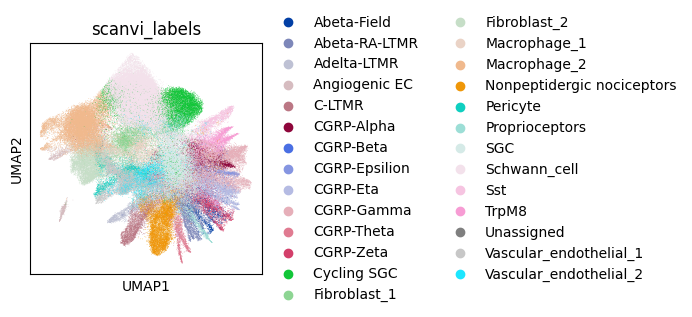

In [61]:
sc.pl.umap(adata_query, color = 'scanvi_labels')

In [64]:
adata_query

AnnData object with n_obs × n_vars = 146276 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'highlight'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_colors', 'neighbors', 'sample_id_colors', 'slide_id_colors', 'umap', 'scanvi_labels_colors'
    obsm: 'X_scVI_ModelB_480', 'X_umap', 'spatial'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

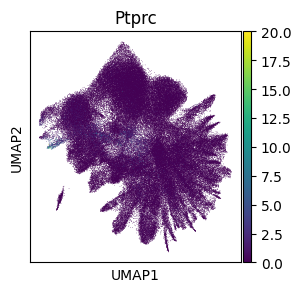

In [63]:
sc.pl.umap(adata_query, color = ['Ptprc'])

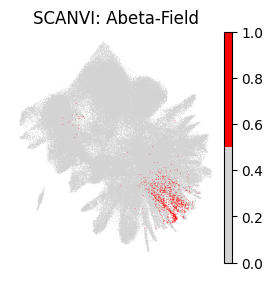

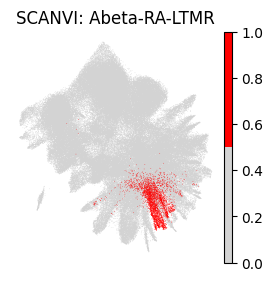

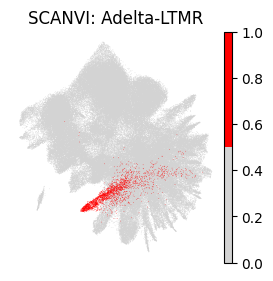

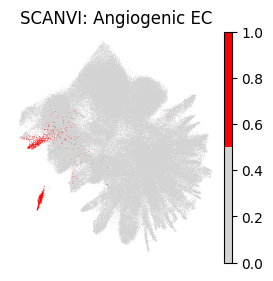

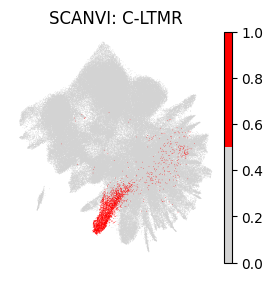

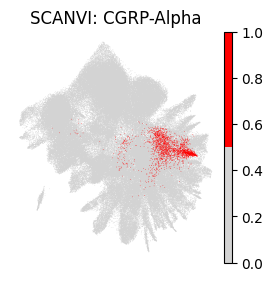

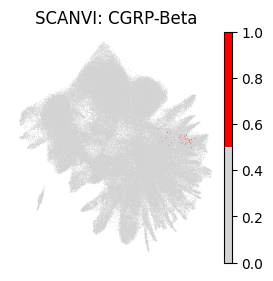

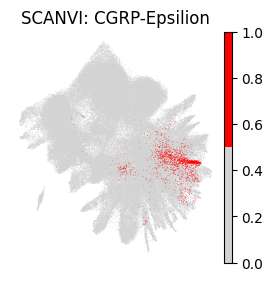

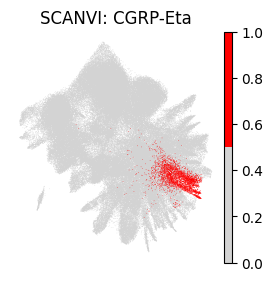

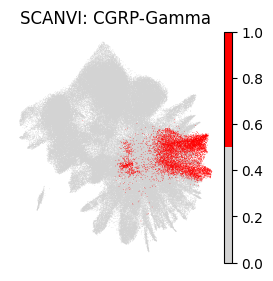

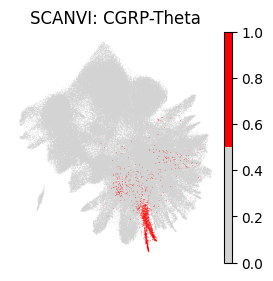

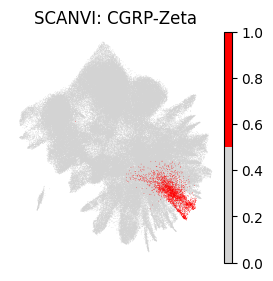

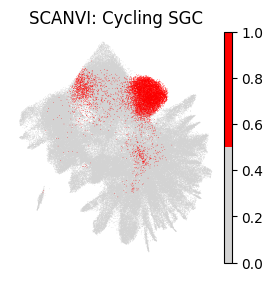

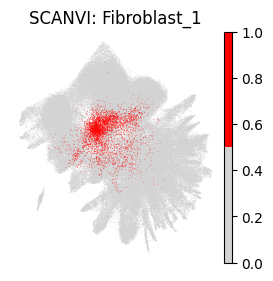

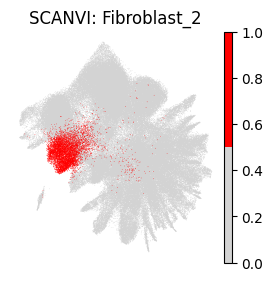

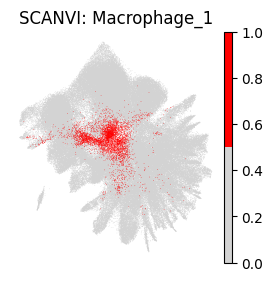

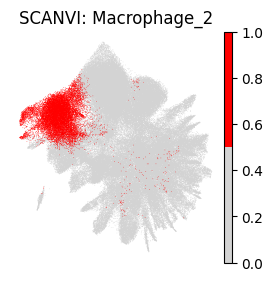

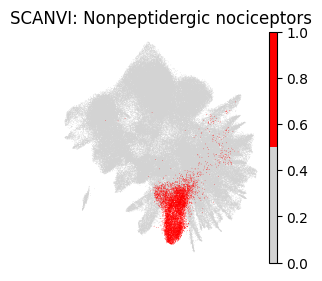

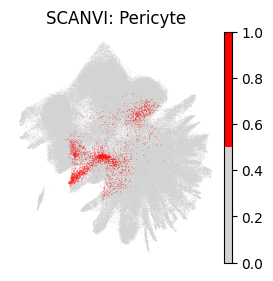

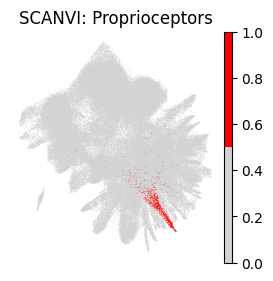

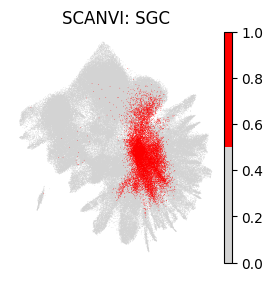

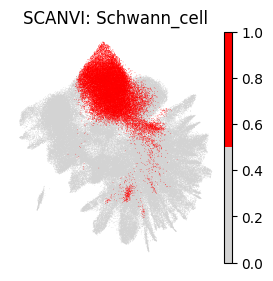

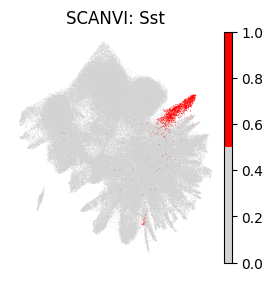

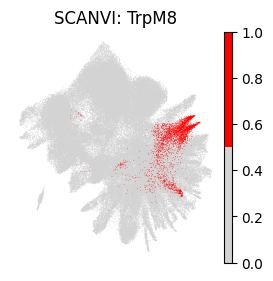

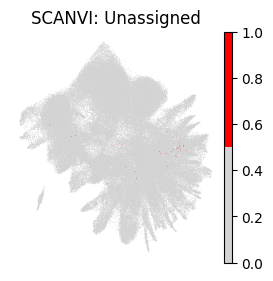

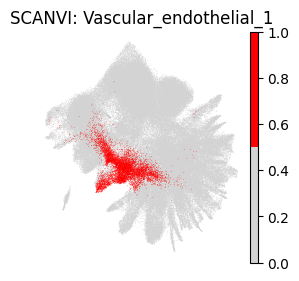

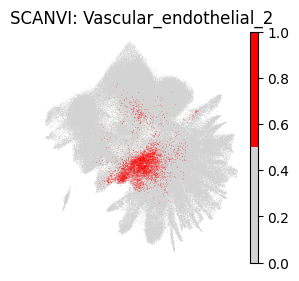

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

red_gray_cmap = ListedColormap(["lightgray", "red"])

for label in adata_query.obs["scanvi_labels"].cat.categories:

    # Create a binary mask: 1 for highlighted cells, 0 for all others
    adata_query.obs["highlight"] = (adata_query.obs["scanvi_labels"] == label).astype(int)

    sc.pl.umap(
        adata_query,
        color="highlight",
        cmap=red_gray_cmap,            # <--- THIS WORKS
        vmin=0, vmax=1,                # ensures correct mapping
        frameon=False,
        title=f"SCANVI: {label}",
        show=True
    )

In [66]:
barcodes = [
    "apeeemip-1-1",
    "bpoikicj-1-1",
    "cbhmmeof-1-1",
    "akcoadof-1-2",
    "bgmdeeeb-1-2",
    "hjjgalia-1-2",
    "hjjkhdhk-1-2",
    "mnhcfodp-1-2",
    "bmjgagok-1-3",
    "ijnggkoc-1-3",
    "llknggjo-1-3",
    "llmfnafp-1-3",
    "llmgffik-1-3",
]

In [67]:
base_barcodes = [bc.split("-")[0] for bc in barcodes]

In [68]:
matches = []

for b in base_barcodes:
    matched_cells = adata_query.obs_names[adata_query.obs_names.str.startswith(b)]
    
    for cell in matched_cells:
        matches.append({
            "barcode_base": b,
            "cell_barcode": cell,
            "scanvi_label": adata_query.obs.loc[cell, "scanvi_labels"]
        })
    

In [69]:
import pandas as pd
df_matches = pd.DataFrame(matches)
df_matches

,barcode_base,cell_barcode,scanvi_label
0,apeeemip,apeeemip-1-1,Vascular_endothelial_1
1,bpoikicj,bpoikicj-1-1,CGRP-Gamma
2,cbhmmeof,cbhmmeof-1-1,CGRP-Gamma
3,akcoadof,akcoadof-1-2,CGRP-Gamma
4,bgmdeeeb,bgmdeeeb-1-2,CGRP-Gamma
5,hjjgalia,hjjgalia-1-2,CGRP-Gamma
6,hjjkhdhk,hjjkhdhk-1-2,CGRP-Gamma
7,mnhcfodp,mnhcfodp-1-2,CGRP-Gamma
8,bmjgagok,bmjgagok-1-3,CGRP-Gamma
9,ijnggkoc,ijnggkoc-1-3,CGRP-Gamma


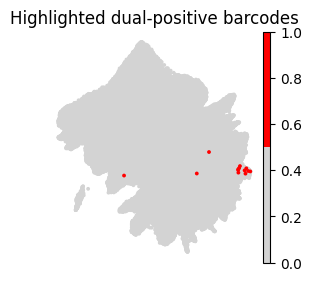

In [74]:
import numpy as np
from matplotlib.colors import ListedColormap
base = [b.split("-")[0] for b in barcodes]
# Create highlight column: 1 = highlight, 0 = gray
adata_query.obs["highlight"] = adata_query.obs_names.str.startswith(tuple(base)).astype(int)

# RED for your barcodes, GRAY for others
cmap = ListedColormap(["lightgray", "red"])

sc.pl.umap(
    adata_query,
    color="highlight",
    cmap=cmap,
    size=30,
    vmin=0, vmax=1,
    frameon=False,
    title="Highlighted dual-positive barcodes"
)

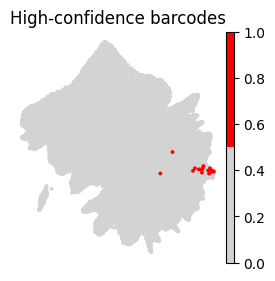

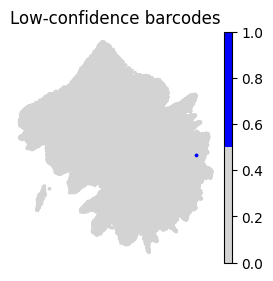

In [80]:
from matplotlib.colors import ListedColormap
import numpy as np

# -----------------------------
# 1. Define barcode prefixes
# -----------------------------
high_barcodes = [
    "cbhmmeof","bpoikicj","agbmnepe","hjjgalia","hjjkhdhk","mnhcfodp",
    "akcoadof","bgmdeeeb","ijnggkoc","bmjgagok","llknggjo","llmfnafp",
    "llmgffik","ikjbpmlk","ebnbhhob","aefmnmje","aapmhgin"
]

low_barcodes = ["bcmkpnkd"]

# -----------------------------
# 2. Plot HIGH-confidence (red)
# -----------------------------
adata_query.obs["highlight"] = adata_query.obs_names.str.startswith(
    tuple(high_barcodes)
).astype(int)

red_gray = ListedColormap(["lightgray", "red"])

sc.pl.umap(
    adata_query,
    color="highlight",
    cmap=red_gray,
    vmin=0, vmax=1,
    size=30,
    frameon=False,
    title="High-confidence barcodes"
)

# -----------------------------
# 3. Plot LOW-confidence (blue)
# -----------------------------
adata_query.obs["highlight"] = adata_query.obs_names.str.startswith(
    tuple(low_barcodes)
).astype(int)

blue_gray = ListedColormap(["lightgray", "blue"])

sc.pl.umap(
    adata_query,
    color="highlight",
    cmap=blue_gray,
    vmin=0, vmax=1,
    size=30,
    frameon=False,
    title="Low-confidence barcodes"
)

In [76]:
import numpy as np
import pandas as pd

# initialize column
adata_query.obs["conf_label"] = "None"

# assign High / Middle / Low based on prefix match
for base, conf in conf_dict.items():
    mask = adata_query.obs_names.str.startswith(base)
    adata_query.obs.loc[mask, "conf_label"] = conf

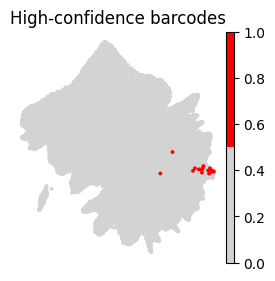

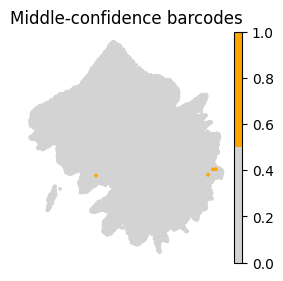

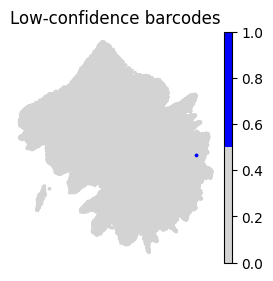

In [81]:
from matplotlib.colors import ListedColormap
import numpy as np

# ---------------------------------------
# 1. Define confidence categories by prefix
# ---------------------------------------
high_barcodes = [
    "cbhmmeof","bpoikicj","agbmnepe","hjjgalia","hjjkhdhk","mnhcfodp",
    "akcoadof","bgmdeeeb","ijnggkoc","bmjgagok","llknggjo","llmfnafp",
    "llmgffik","ikjbpmlk","ebnbhhob","aefmnmje","aapmhgin"
]

middle_barcodes = [
    "aallcopa","acpnmbio","apeeemip","iidhhibl"
]

low_barcodes = [
    "bcmkpnkd"
]

# ---------------------------------------
# 2. Create one unified confidence column
# ---------------------------------------
adata_query.obs["conf_label"] = "None"  # default

# assign high
mask_high = adata_query.obs_names.str.startswith(tuple(high_barcodes))
adata_query.obs.loc[mask_high, "conf_label"] = "High"

# assign middle
mask_middle = adata_query.obs_names.str.startswith(tuple(middle_barcodes))
adata_query.obs.loc[mask_middle, "conf_label"] = "Middle"

# assign low
mask_low = adata_query.obs_names.str.startswith(tuple(low_barcodes))
adata_query.obs.loc[mask_low, "conf_label"] = "Low"

# ---------------------------------------
# 3. Plot separate UMAPs for each confidence group
# ---------------------------------------

# High = red
adata_query.obs["highlight"] = (adata_query.obs["conf_label"] == "High").astype(int)
cmap_red = ListedColormap(["lightgray", "red"])
sc.pl.umap(
    adata_query,
    color="highlight",
    cmap=cmap_red,
    vmin=0, vmax=1,
    size=30,
    frameon=False,
    title="High-confidence barcodes"
)

# Middle = orange
adata_query.obs["highlight"] = (adata_query.obs["conf_label"] == "Middle").astype(int)
cmap_orange = ListedColormap(["lightgray", "orange"])
sc.pl.umap(
    adata_query,
    color="highlight",
    cmap=cmap_orange,
    vmin=0, vmax=1,
    size=30,
    frameon=False,
    title="Middle-confidence barcodes"
)

# Low = blue
adata_query.obs["highlight"] = (adata_query.obs["conf_label"] == "Low").astype(int)
cmap_blue = ListedColormap(["lightgray", "blue"])
sc.pl.umap(
    adata_query,
    color="highlight",
    cmap=cmap_blue,
    vmin=0, vmax=1,
    size=30,
    frameon=False,
    title="Low-confidence barcodes"
)

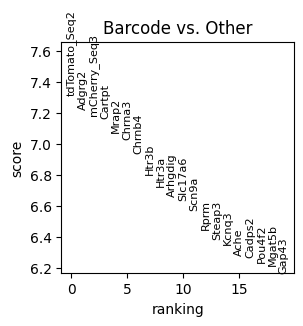

In [83]:
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

# ---------------------------------------
# 1. Define barcode prefixes
# ---------------------------------------
high_barcodes = [
    "cbhmmeof","bpoikicj","agbmnepe","hjjgalia","hjjkhdhk","mnhcfodp",
    "akcoadof","bgmdeeeb","ijnggkoc","bmjgagok","llknggjo","llmfnafp",
    "llmgffik","ikjbpmlk","ebnbhhob","aefmnmje","aapmhgin"
]

middle_barcodes = [
    "aallcopa","acpnmbio","apeeemip","iidhhibl"
]

low_barcodes = [
    "bcmkpnkd"
]

# Combine all barcode prefixes
all_barcodes = list(set(high_barcodes + middle_barcodes + low_barcodes))

# ---------------------------------------
# 2. Mark barcode cells (Barcode vs Other)
# ---------------------------------------
adata_query.obs["is_barcode"] = adata_query.obs_names.str.startswith(
    tuple(all_barcodes)
).astype(int)

adata_query.obs["is_barcode"] = adata_query.obs["is_barcode"].map({0: "Other", 1: "Barcode"})
adata_query.obs["is_barcode"] = adata_query.obs["is_barcode"].astype("category")

# ---------------------------------------
# 3. Normalize + log-transform before DE
# ---------------------------------------
sc.pp.normalize_total(adata_query, target_sum=1e4)
sc.pp.log1p(adata_query)

# ---------------------------------------
# 4. Run Wilcoxon differential expression
# ---------------------------------------
sc.tl.rank_genes_groups(
    adata_query,
    groupby="is_barcode",
    groups=["Barcode"],
    reference="Other",
    method="wilcoxon"
)

# ---------------------------------------
# 5. Plot top 20 DE genes
# ---------------------------------------
sc.pl.rank_genes_groups(adata_query, groups=["Barcode"], n_genes=20)

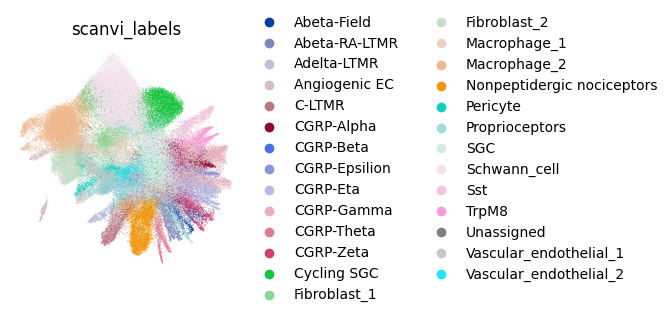

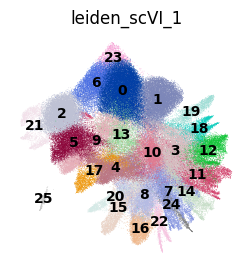

In [111]:
sc.pl.umap(adata_query, color = ['scanvi_labels'], frameon = False)
sc.pl.umap(adata_query, color = ['leiden_scVI_1'], legend_loc = 'on data', frameon = False)

In [101]:
adata_query.obs.scanvi_labels.value_counts()

scanvi_labels
Schwann_cell                  29991
Macrophage_2                  16102
SGC                           14140
Cycling SGC                    9675
CGRP-Gamma                     8488
Nonpeptidergic nociceptors     7713
Vascular_endothelial_1         7692
Fibroblast_2                   6905
Macrophage_1                   4617
Fibroblast_1                   4554
Vascular_endothelial_2         3858
TrpM8                          3613
CGRP-Eta                       3582
Abeta-RA-LTMR                  3473
C-LTMR                         3115
Pericyte                       2816
CGRP-Zeta                      2740
Adelta-LTMR                    2267
CGRP-Alpha                     2233
Sst                            1903
CGRP-Epsilion                  1793
CGRP-Theta                     1700
Abeta-Field                    1202
Angiogenic EC                  1034
Proprioceptors                  989
CGRP-Beta                        45
Unassigned                       36
Name: count, d

Clusters used for DE:
leiden_scVI_1
3     3155
12    2912
11    1896
4      297
13      76
8       55
15      31
17      20
18      11
14      10
19      10
22       5
9        3
16       3
7        2
Name: count, dtype: int64


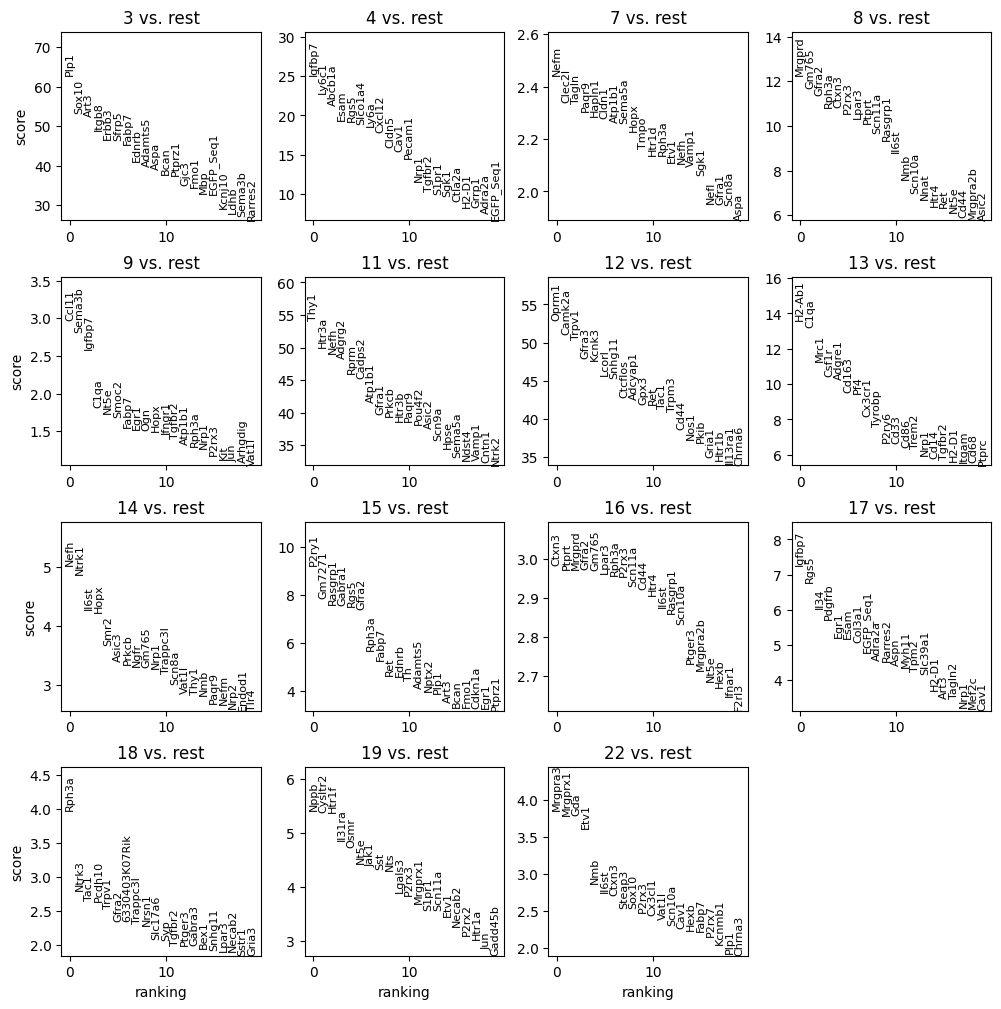

In [104]:
# Subset CGRP_gamma cells
subset = adata_query[adata_query.obs["scanvi_labels"] == "CGRP-Gamma"].copy()

# Normalize + log
#sc.pp.normalize_total(subset, target_sum=1e4)
#sc.pp.log1p(subset)

# Make sure Leiden is categorical
subset.obs["leiden_scVI_1"] = subset.obs["leiden_scVI_1"].astype("category")

# -----------------------------
# Remove Leiden clusters with < 2 cells
# -----------------------------
counts = subset.obs["leiden_scVI_1"].value_counts()
valid = counts[counts >= 2].index
subset = subset[subset.obs["leiden_scVI_1"].isin(valid)].copy()

print("Clusters used for DE:")
print(subset.obs["leiden_scVI_1"].value_counts())

# -----------------------------
# Run Wilcoxon DE
# -----------------------------
sc.tl.rank_genes_groups(
    subset,
    groupby="leiden_scVI_1",
    method="wilcoxon"
)

# Plot
sc.pl.rank_genes_groups(subset, n_genes=20, sharey=False)

In [109]:
# ----------------------------
# 1. Define barcode prefixes
# ----------------------------
prefixes = [
    "aallcopa","acpnmbio","cbhmmeof","bpoikicj","apeeemip",
    "agbmnepe","hjjgalia","hjjkhdhk","mnhcfodp","akcoadof",
    "bgmdeeeb","ijnggkoc","bmjgagok","llknggjo","llmfnafp",
    "llmgffik","ikjbpmlk","ebnbhhob","aefmnmje","bcmkpnkd",
    "iidhhibl","aapmhgin"
]

# ----------------------------
# 2. Find matching cells
# ----------------------------
matches = adata_query.obs_names[
    adata_query.obs_names.str.startswith(tuple(prefixes))
]

print("Matched cells:")
print(matches)

# ----------------------------
# 3. Show each barcode's cluster + label
# ----------------------------
print("\nBarcode cluster assignments:\n")
print(adata_query.obs.loc[matches, ["leiden_scVI_1", "scanvi_labels"]])

# ----------------------------
# 4. Count how many barcodes per cluster
# ----------------------------
print("\nCounts per Leiden cluster:")
print(adata_query.obs.loc[matches, "leiden_scVI_1"].value_counts())

Matched cells:
Index(['aallcopa-1-0', 'acpnmbio-1-0', 'agbmnepe-1-1', 'apeeemip-1-1',
       'bpoikicj-1-1', 'cbhmmeof-1-1', 'akcoadof-1-2', 'bgmdeeeb-1-2',
       'hjjgalia-1-2', 'hjjkhdhk-1-2', 'mnhcfodp-1-2', 'bmjgagok-1-3',
       'ijnggkoc-1-3', 'llknggjo-1-3', 'llmfnafp-1-3', 'llmgffik-1-3',
       'aapmhgin-1-4', 'aefmnmje-1-6', 'bcmkpnkd-1-6', 'iidhhibl-1-6',
       'ebnbhhob-1-7', 'ikjbpmlk-1-7'],
      dtype='object')

Barcode cluster assignments:

             leiden_scVI_1           scanvi_labels
aallcopa-1-0            11              CGRP-Gamma
acpnmbio-1-0            11              CGRP-Gamma
agbmnepe-1-1            11              CGRP-Gamma
apeeemip-1-1            17  Vascular_endothelial_1
bpoikicj-1-1            11              CGRP-Gamma
cbhmmeof-1-1            11              CGRP-Gamma
akcoadof-1-2            11              CGRP-Gamma
bgmdeeeb-1-2            11              CGRP-Gamma
hjjgalia-1-2            11              CGRP-Gamma
hjjkhdhk-1-2            14 

In [108]:
adata_query.obs.scanvi_labels.value_counts()

scanvi_labels
Schwann_cell                  29991
Macrophage_2                  16102
SGC                           14140
Cycling SGC                    9675
CGRP-Gamma                     8488
Nonpeptidergic nociceptors     7713
Vascular_endothelial_1         7692
Fibroblast_2                   6905
Macrophage_1                   4617
Fibroblast_1                   4554
Vascular_endothelial_2         3858
TrpM8                          3613
CGRP-Eta                       3582
Abeta-RA-LTMR                  3473
C-LTMR                         3115
Pericyte                       2816
CGRP-Zeta                      2740
Adelta-LTMR                    2267
CGRP-Alpha                     2233
Sst                            1903
CGRP-Epsilion                  1793
CGRP-Theta                     1700
Abeta-Field                    1202
Angiogenic EC                  1034
Proprioceptors                  989
CGRP-Beta                        45
Unassigned                       36
Name: count, d

In [115]:
# Make a copy for safety
adata_query.obs["scanvi_labels_smooth"] = adata_query.obs["scanvi_labels"]

# Perform majority voting per Leiden cluster
for cluster in adata_query.obs["leiden_scVI_1"].cat.categories:
    # cells in this Leiden cluster
    mask = adata_query.obs["leiden_scVI_1"] == cluster
    
    # the most common SCANVI label in this cluster
    majority_label = (
        adata_query.obs.loc[mask, "scanvi_labels"]
        .value_counts()
        .idxmax()
    )
    
    # assign smoothed label
    adata_query.obs.loc[mask, "scanvi_labels_smooth"] = majority_label

print("Done. New labels stored in adata_query.obs['scanvi_labels_smooth']")

Done. New labels stored in adata_query.obs['scanvi_labels_smooth']


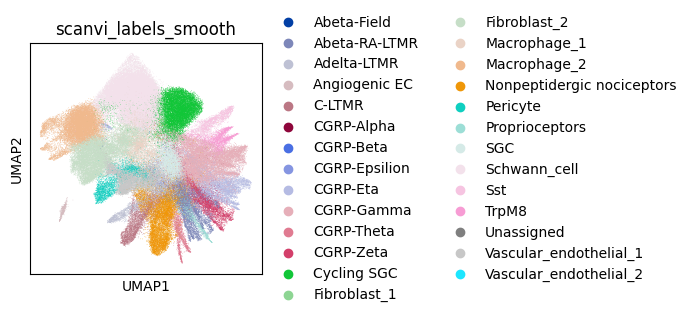

In [117]:
sc.pl.umap(adata_query, color = 'scanvi_labels_smooth')

In [118]:
# Build a dataframe mapping barcodes → cluster + labels
barcode_table = adata_query.obs.loc[
    matches,
    ["leiden_scVI_1", "scanvi_labels", "scanvi_labels_smooth"]
].copy()

# Add a prefix column for clarity
barcode_table["barcode_prefix"] = barcode_table.index.str.split("-").str[0]

# Reorder columns
barcode_table = barcode_table[[
    "barcode_prefix",
    "leiden_scVI_1",
    "scanvi_labels",
    "scanvi_labels_smooth"
]]

print(barcode_table)

             barcode_prefix leiden_scVI_1           scanvi_labels  \
aallcopa-1-0       aallcopa            11              CGRP-Gamma   
acpnmbio-1-0       acpnmbio            11              CGRP-Gamma   
agbmnepe-1-1       agbmnepe            11              CGRP-Gamma   
apeeemip-1-1       apeeemip            17  Vascular_endothelial_1   
bpoikicj-1-1       bpoikicj            11              CGRP-Gamma   
cbhmmeof-1-1       cbhmmeof            11              CGRP-Gamma   
akcoadof-1-2       akcoadof            11              CGRP-Gamma   
bgmdeeeb-1-2       bgmdeeeb            11              CGRP-Gamma   
hjjgalia-1-2       hjjgalia            11              CGRP-Gamma   
hjjkhdhk-1-2       hjjkhdhk            14              CGRP-Gamma   
mnhcfodp-1-2       mnhcfodp            11              CGRP-Gamma   
bmjgagok-1-3       bmjgagok            11              CGRP-Gamma   
ijnggkoc-1-3       ijnggkoc            11              CGRP-Gamma   
llknggjo-1-3       llknggjo       